# MNIST Digits Classifier Using CNN 

In [1]:
# Imports

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

# Ensure reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
class MNISTClassifier(nn.Module):
    """
    Highly accurate CNN classifier for the MNIST dataset.
    Follows a 2-loop Convolution-Pooling feature extraction structure,
    followed by a standard regularized feed-forward network.
    """
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        
        # Loop 1: Feature Extraction
        # Input channel: 1 (grayscale), Output: 32 filters, Kernel: 3x3, Stride: 1, Padding: 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Loop 2: Feature Extraction
        # Input: 32 channels, Output: 64 filters, Kernel: 3x3, Stride: 1, Padding: 1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(num_features=64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully Connected (Dense) Layers
        # 64 channels * 7x7 spatial dimensions = 3136 features
        self.fc1 = nn.Linear(in_features=3136, out_features=128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        # Input tensor shape: [batch_size, 1, 28, 28]
        
        # Loop 1 Feature Extraction
        x = self.conv1(x)        # Shape: [batch_size, 32, 28, 28]
        x = self.bn1(x)          # Shape: [batch_size, 32, 28, 28]
        x = self.relu1(x)        # Shape: [batch_size, 32, 28, 28]
        x = self.pool1(x)        # Shape: [batch_size, 32, 14, 14]
        
        # Loop 2 Feature Extraction
        x = self.conv2(x)        # Shape: [batch_size, 64, 14, 14]
        x = self.bn2(x)          # Shape: [batch_size, 64, 14, 14]
        x = self.relu2(x)        # Shape: [batch_size, 64, 14, 14]
        x = self.pool2(x)        # Shape: [batch_size, 64, 7, 7]
        
        # Flattening 3D feature map to 1D vector
        x = x.view(x.size(0), -1) # Shape: [batch_size, 3136]
        
        # Fully Connected Layers
        x = self.fc1(x)          # Shape: [batch_size, 128]
        x = self.relu3(x)        # Shape: [batch_size, 128]
        x = self.dropout(x)      # Shape: [batch_size, 128]
        x = self.fc2(x)          # Shape: [batch_size, 10]
        
        # No Softmax activation layer is applied at the end because 
        # nn.CrossEntropyLoss internally applies log-softmax for stability.
        return x

In [3]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Performs training over a single epoch.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, targets) in enumerate(dataloader):
        images, targets = images.to(device), targets.to(device)
        
        # 1. Zero the parameter gradients
        optimizer.zero_grad()
        
        # 2. Forward pass
        outputs = model(images)
        
        # 3. Compute loss
        loss = criterion(outputs, targets)
        
        # 4. Backward pass
        loss.backward()
        
        # 5. Optimizer step
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [4]:
def evaluate(model, dataloader, criterion, device, return_predictions=False):
    """
    Evaluates the model on the test dataset.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_targets = []
    
    # Wrap in torch.no_grad() to disable gradient computation and save memory
    with torch.no_grad():
        for images, targets in dataloader:
            images, targets = images.to(device), targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            if return_predictions:
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                
    test_loss = running_loss / total
    test_acc = 100.0 * correct / total
    
    if return_predictions:
        return test_loss, test_acc, np.array(all_preds), np.array(all_targets)
    return test_loss, test_acc, None, None


In [6]:
def evaluate(model, dataloader, criterion, device, return_predictions=False):
    """
    Evaluates the model on the test dataset.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_targets = []
    
    # Wrap in torch.no_grad() to disable gradient computation and save memory
    with torch.no_grad():
        for images, targets in dataloader:
            images, targets = images.to(device), targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            if return_predictions:
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                
    test_loss = running_loss / total
    test_acc = 100.0 * correct / total
    
    if return_predictions:
        return test_loss, test_acc, np.array(all_preds), np.array(all_targets)
    return test_loss, test_acc, None, None


Using CPU for training.

Starting training for 15 epochs...


c:\Users\VED PRADHAN\Desktop\Ved\MNIST CNN (PyTorch)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/15 | Train Loss: 0.4405 | Train Acc: 86.08% | Test Loss: 0.0506 | Test Acc: 98.28% | Duration: 67.4s
Epoch 02/15 | Train Loss: 0.2091 | Train Acc: 93.59% | Test Loss: 0.0425 | Test Acc: 98.70% | Duration: 57.3s
Epoch 03/15 | Train Loss: 0.1760 | Train Acc: 94.75% | Test Loss: 0.0332 | Test Acc: 98.82% | Duration: 60.3s
Epoch 04/15 | Train Loss: 0.1521 | Train Acc: 95.43% | Test Loss: 0.0373 | Test Acc: 98.83% | Duration: 57.8s
Epoch 05/15 | Train Loss: 0.1391 | Train Acc: 95.84% | Test Loss: 0.0331 | Test Acc: 98.87% | Duration: 56.6s
Epoch 06/15 | Train Loss: 0.1318 | Train Acc: 96.07% | Test Loss: 0.0275 | Test Acc: 99.13% | Duration: 66.3s
Epoch 07/15 | Train Loss: 0.1213 | Train Acc: 96.32% | Test Loss: 0.0267 | Test Acc: 99.00% | Duration: 73.6s
Epoch 08/15 | Train Loss: 0.1110 | Train Acc: 96.63% | Test Loss: 0.0271 | Test Acc: 99.10% | Duration: 70.0s
Epoch 09/15 | Train Loss: 0.1039 | Train Acc: 96.85% | Test Loss: 0.0262 | Test Acc: 99.24% | Duration: 65.1s
Epoch 10/1

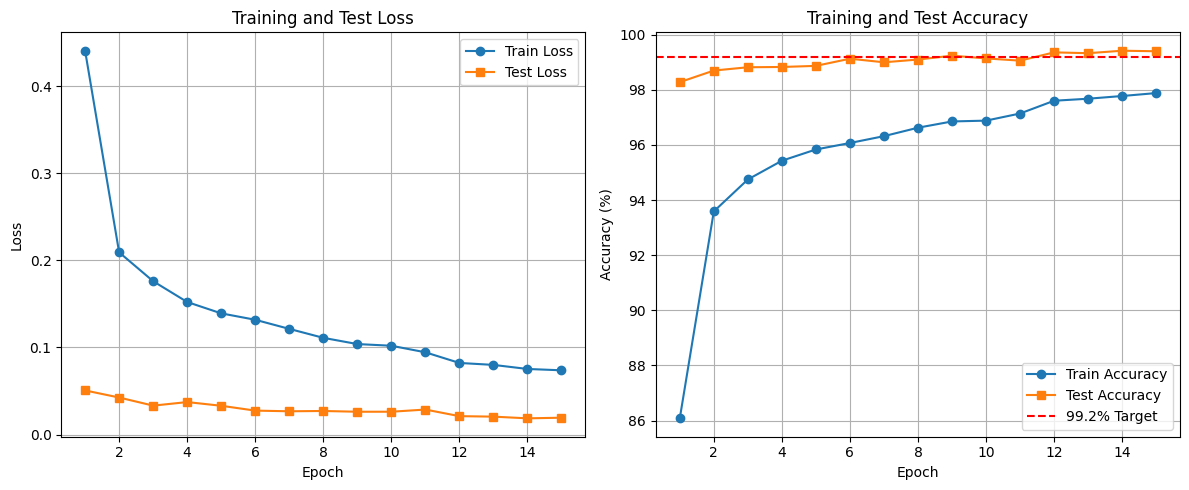

In [ ]:
def main():
    # 1. Device selection: Hardware-agnostic accelerator setup
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using GPU (CUDA) for training.")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using GPU (MPS) for training.")
    else:
        device = torch.device("cpu")
        print("Using CPU for training.")

    # 2. Data Ingestion & Preprocessing
    # Global MNIST stats for normalization
    mnist_mean = (0.1307,)
    mnist_std = (0.3081,)
    
    # Augmentations for training to boost generalization and prevent overfitting
    train_transforms = transforms.Compose([
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mnist_mean, mnist_std)
    ])
    
    # Normalization only for test set
    test_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mnist_mean, mnist_std)
    ])
    
    print("Downloading and preparing MNIST dataset...")
    # Load dataset with automatic download
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transforms)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=test_transforms)
    
    print("MNIST dataset download/preparation completed.")
    
    # Setup DataLoaders with specifications
    train_loader = DataLoader(
        train_dataset, 
        batch_size=128, 
        shuffle=True, 
        num_workers=2, 
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=1000, 
        shuffle=False, 
        num_workers=2, 
        pin_memory=True
    )
    
    # 3. Model instantiation
    model = MNISTClassifier().to(device)
    
    # 4. Training specifications
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    # Scheduler: Reduce learning rate when validation loss has stopped improving
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=1
    )
    
    epochs = 15
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    print(f"\nStarting training for {epochs} epochs...")
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        
        # Train and evaluate
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
        
        # Step the scheduler based on test/validation loss
        scheduler.step(test_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        epoch_duration = time.time() - epoch_start
        print(f"Epoch {epoch:02d}/{epochs:02d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
              f"Duration: {epoch_duration:.1f}s")
              
    total_duration = time.time() - start_time
    print(f"\nTraining completed in {total_duration/60:.2f} minutes.")
    
    # 5. Final Evaluation and Metrics
    print("\nRunning final evaluation for classification report and confusion matrix...")
    _, final_accuracy, predictions, targets = evaluate(
        model, test_loader, criterion, device, return_predictions=True
    )
    
    # Validate final prediction outputs before metrics generation
    if predictions is None or targets is None:
        raise RuntimeError("Expected predictions and targets from evaluate(..., return_predictions=True).")
    if predictions.shape != targets.shape:
        raise ValueError(
            f"Predictions and targets must have the same shape, got "
            f"{predictions.shape} vs {targets.shape}"
        )
    
    print(f"Final Test Accuracy: {final_accuracy:.2f}%")
    
    # Print classification report
    print("\n--- Classification Report ---")
    print(classification_report(targets, predictions, digits=4, zero_division=0, labels=list(range(10))))
    
    # Print confusion matrix
    print("--- Confusion Matrix ---")
    print(confusion_matrix(targets, predictions, labels=list(range(10))))
    
    # 6. Plotting training curves
    plt.figure(figsize=(12, 5))
    
    # Plot Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', marker='o')
    plt.plot(range(1, epochs + 1), history['test_loss'], label='Test Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss')
    plt.grid(True)
    plt.legend()
    
    # Plot Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(range(1, epochs + 1), history['test_acc'], label='Test Accuracy', marker='s')
    plt.axhline(y=99.2, color='r', linestyle='--', label='99.2% Target')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Test Accuracy')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plot_path = 'training_curves.png'
    plt.savefig(plot_path, dpi=300)
    print(f"\nSaved training curves to {os.path.abspath(plot_path)}")


if __name__ == '__main__':
    main()
